# Registration Evaluation

**Warning!** This notebook is **deprecated!** It evaluates and visualizes intermediary results of series registrations. For the evaluation and visualization of the final experiments, see `Final_Eval.ipynb`.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import t
import math
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

from leafalignment.utils import convert_image_to_tensor
from leafalignment.plotting import plot_image_pair, plot_image_series
from leafalignment.registration import fetch_registered_image_mask_pair
from leafalignment.DatasetTools.LeafImageSeries import LeafDataset

In [2]:
df_full = pd.read_csv("../results/seq_registration.csv")
df_full.head()

,leaf_uid,registration_method,leaf_style,fixed_image,moving_image,MSE,NCC,MI,SSIM,IoU,Hausdorff
0,ESWW0070020_1,Piecewise Affine,Leaf ROI,0,1,0.006813,0.015722,1.009170,0.347665,0.948756,62.987316
1,ESWW0070020_1,Piecewise Affine,Leaf ROI,0,2,0.024689,0.010441,1.005553,0.272924,0.948640,62.987316
2,ESWW0070020_1,Piecewise Affine,Leaf ROI,0,3,0.010441,0.018857,1.005519,0.291469,0.948681,62.987316
3,ESWW0070020_1,Piecewise Affine,Leaf ROI,0,4,0.033797,0.022684,1.006689,0.248420,0.948755,62.987316
4,ESWW0070020_1,Piecewise Affine,Leaf ROI,0,5,0.035394,-0.009654,1.004894,0.243832,0.948741,62.987316


In [3]:
n_uids = df_full['leaf_uid'].nunique()
print(f"Number of leafs evaluated: {n_uids}")

Number of leafs evaluated: 59


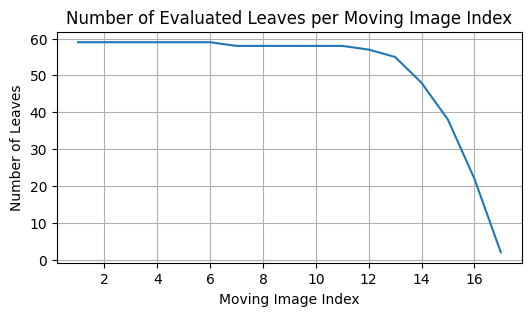

In [7]:
moving_img_ind_count = df_full[df_full["registration_method"] == "LoFTR + TPS Semi-Sequential"]['moving_image'].value_counts()
plt.figure(figsize=(6, 3))
plt.plot(moving_img_ind_count.index, moving_img_ind_count.values)
plt.title("Number of Evaluated Leaves per Moving Image Index")
plt.xlabel("Moving Image Index")
plt.ylabel("Number of Leaves")
plt.grid()
plt.show()

In [9]:
metrics = ["MSE", "NCC", "MI", "SSIM", "IoU", "Hausdorff"]
group_cols = ['registration_method', 'leaf_style', 'fixed_image', 'moving_image']
methods = df_full["registration_method"].unique()

## Averages per time step

In [10]:
# average over leaf series for each index pair
df_agg = df_full.groupby(group_cols)[metrics].agg(["mean", "std"]).reset_index()
df_agg.columns = [ "_".join(col).rstrip("_") for col in df_agg.columns ]
df_agg.sample(5).sort_values(by=(group_cols))

,registration_method,leaf_style,fixed_image,moving_image,MSE_mean,MSE_std,NCC_mean,NCC_std,MI_mean,MI_std,SSIM_mean,SSIM_std,IoU_mean,IoU_std,Hausdorff_mean,Hausdorff_std
5,LoFTR + TPS Filtered Sequential,Leaf ROI,0,6,0.017158,0.009785,0.022143,0.044047,1.006750,0.005317,0.664442,0.078523,0.875694,0.090786,63.739446,63.531919
13,LoFTR + TPS Filtered Sequential,Leaf ROI,0,14,0.040342,0.024280,-0.001625,0.011134,1.006104,0.007571,0.610671,0.083493,0.795412,0.117399,100.389298,76.970614
14,LoFTR + TPS Filtered Sequential,Leaf ROI,0,15,0.035685,0.012732,0.000405,0.015214,1.004332,0.006082,0.618404,0.051383,0.774696,0.128182,98.509463,85.426419
43,LoFTR + TPS Semi-Sequential,Leaf ROI,0,11,0.031885,0.022350,0.049276,0.081193,1.009507,0.008924,0.681016,0.059045,0.906734,0.067153,48.372051,55.081974
52,Piecewise Affine,Leaf ROI,0,3,0.013808,0.007368,0.120937,0.075364,1.021762,0.010847,0.379050,0.079266,0.917329,0.031205,114.928710,96.094786


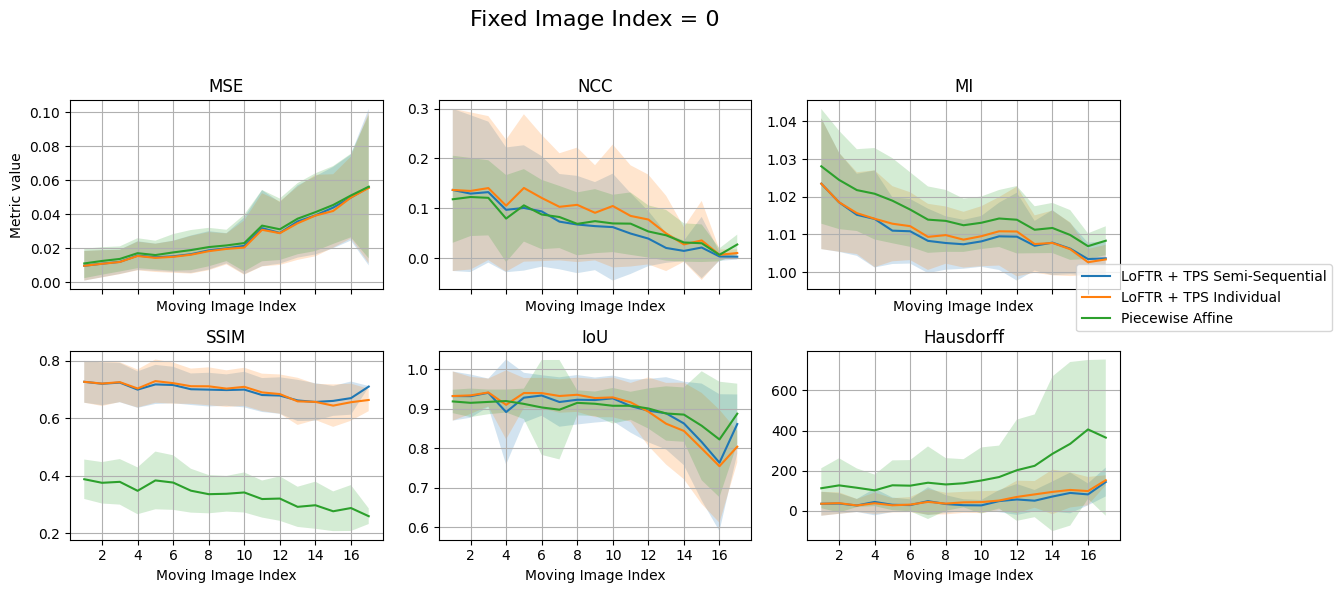

In [11]:
methods = ["LoFTR + TPS Semi-Sequential", "LoFTR + TPS Individual", "Piecewise Affine"]
n_metrics = len(metrics)

n_rows = 2
n_cols = math.ceil(n_metrics / n_rows)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(4 * n_cols, 3 * n_rows),
    sharex=True,
    sharey=False
)

axes = axes.flatten()

for ax, metric in zip(axes, metrics):
    for method in methods:
        df_plot = df_agg[
            (df_agg["fixed_image"] == 0) &
            (df_agg["registration_method"] == method) &
            (df_agg["moving_image"] != 0)
        ].sort_values("moving_image")

        if df_plot.empty:
            continue

        x = df_plot["moving_image"]
        mean = df_plot[f"{metric}_mean"]
        std = df_plot[f"{metric}_std"]

        ax.plot(x, mean, label=method)
        ax.fill_between(x, mean - std, mean + std, alpha=0.2, label="_nolegend_")

    ax.set_title(metric)
    ax.grid(True)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.set_xlabel("Moving Image Index")

# hide unused subplots
for ax in axes[len(metrics):]:
    ax.set_visible(False)

# shared y-label
axes[0].set_ylabel("Metric value")

# put legend far right outside
fig.legend(
    methods,
    loc="center right",
    bbox_to_anchor=(1.12, 0.5)
)

fig.suptitle("Fixed Image Index = 0", fontsize=16)

# tighten layout to remove empty space
fig.tight_layout(rect=[0, 0, 0.95, 0.95])
plt.show()


## Distribution over leaves (averages over moving image index)

In [12]:
# average over leaf series over each index pair
df_agg_leaf = df_full.groupby(['leaf_uid', 'registration_method', 'leaf_style'])[metrics].agg(["mean", "std"]).reset_index()
df_agg_leaf.columns = [ "_".join(col).rstrip("_") for col in df_agg_leaf.columns ]
df_agg_leaf.sample(5).sort_values(by=(['registration_method']))

,leaf_uid,registration_method,leaf_style,MSE_mean,MSE_std,NCC_mean,NCC_std,MI_mean,MI_std,SSIM_mean,SSIM_std,IoU_mean,IoU_std,Hausdorff_mean,Hausdorff_std
28,ESWW0070020_7,LoFTR + TPS Filtered Sequential,Leaf ROI,0.015939,0.011039,0.159462,0.197601,1.013018,0.008392,0.663795,0.067648,0.943695,0.014008,21.674081,7.170801
64,ESWW0070023_6,LoFTR + TPS Filtered Sequential,Leaf ROI,0.021090,0.011119,0.010433,0.027506,1.005420,0.005267,0.601424,0.030730,0.828798,0.044009,116.382356,24.804871
161,ESWW0070044_2,LoFTR + TPS Individual,Leaf ROI,0.014319,0.008899,0.062544,0.050287,1.022298,0.014690,0.755445,0.035848,0.919892,0.094151,51.313043,98.755011
158,ESWW0070044_1,LoFTR + TPS Semi-Sequential,Leaf ROI,0.012915,0.001289,0.033357,0.045113,1.007084,0.008913,0.640898,0.075572,0.849619,0.172690,75.866196,97.391508
222,ESWW0070054_19,LoFTR + TPS Semi-Sequential,Leaf ROI,0.022977,0.030963,0.123762,0.163432,1.013100,0.011853,0.754361,0.062181,0.920336,0.121739,36.304302,57.188380


In [13]:
df_agg_leaf_melt = df_agg_leaf.melt(id_vars=['leaf_uid','registration_method', 'leaf_style'], value_vars=['MSE_mean', 'NCC_mean', 'MI_mean', 'SSIM_mean', 'IoU_mean', 'Hausdorff_mean'],)
df_agg_leaf_melt.sample(5)

,leaf_uid,registration_method,leaf_style,variable,value
116,ESWW0070040_1,LoFTR + TPS Filtered Sequential,Leaf ROI,MSE_mean,0.020017
945,ESWW0070023_2,LoFTR + TPS Individual,Leaf ROI,IoU_mean,0.914691
1257,ESWW0070040_5,LoFTR + TPS Individual,Leaf ROI,Hausdorff_mean,48.844172
811,ESWW0070040_5,Piecewise Affine,Leaf ROI,SSIM_mean,0.338047
823,ESWW0070040_8,Piecewise Affine,Leaf ROI,SSIM_mean,0.390949


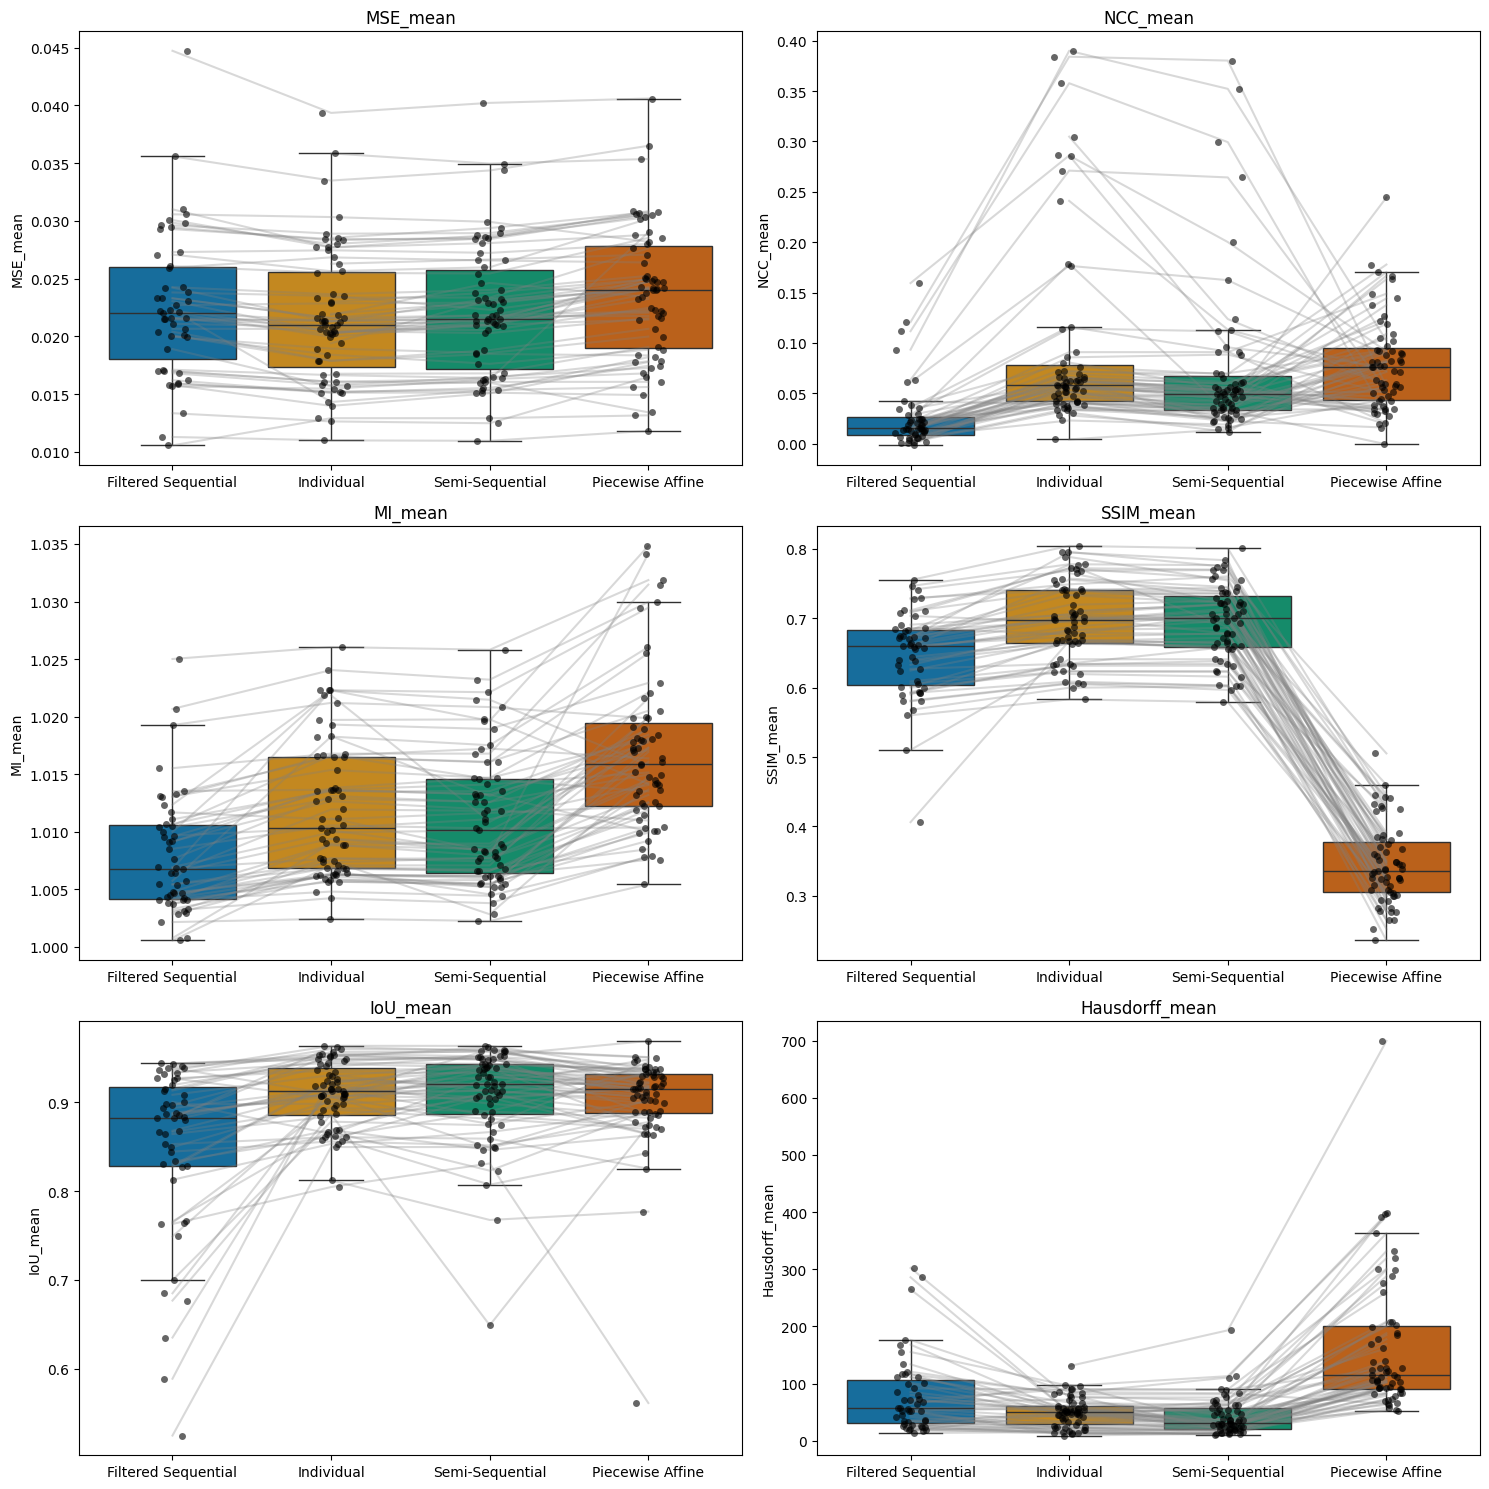

In [19]:
def plot_metrics_boxplots(df, metrics, method_col="registration_method", value_col="value", id_col="leaf_uid", plot_lines=False):
    n_metrics = len(metrics)

    fig, axes = plt.subplots(
        nrows=3,
        ncols=2,
        figsize=(15, 15),
        sharey=False
    )

    axes = axes.flatten()

    methods = df[method_col].str.replace("LoFTR + TPS ", "", n=1, regex=False).unique()
    palette = dict(zip(methods, sns.color_palette("colorblind", len(methods))))

    for ax, metric in zip(axes, metrics):
        data_m = df[df["variable"] == metric]
        data_m.loc[:, method_col] = data_m[method_col].str.replace("LoFTR + TPS ", "", n=1, regex=False)

        sns.boxplot(
            data=data_m,
            x=method_col,
            y=value_col,
            ax=ax,
            hue=method_col,
            palette=palette,
            showfliers=False
        )

        sns.stripplot(
            data=data_m,
            x=method_col,
            y=value_col,
            ax=ax,
            color="black",
            alpha=0.6,
            jitter=True
        )

        if plot_lines:
            sns.lineplot(
                data=data_m,
                x=method_col,
                y=value_col,
                units="leaf_uid",
                estimator=None,
                color="gray",
                alpha=0.3,
                ax=ax
            )


        ax.set_title(metric)
        ax.set_xlabel("")
        ax.set_ylabel(metric)

    # Remove unused axes if metrics < grid size
    for ax in axes[len(metrics):]:
        ax.remove()

    plt.tight_layout()
    plt.show()

plot_metrics_boxplots(df_agg_leaf_melt, [metric + "_mean" for metric in metrics], plot_lines=True)

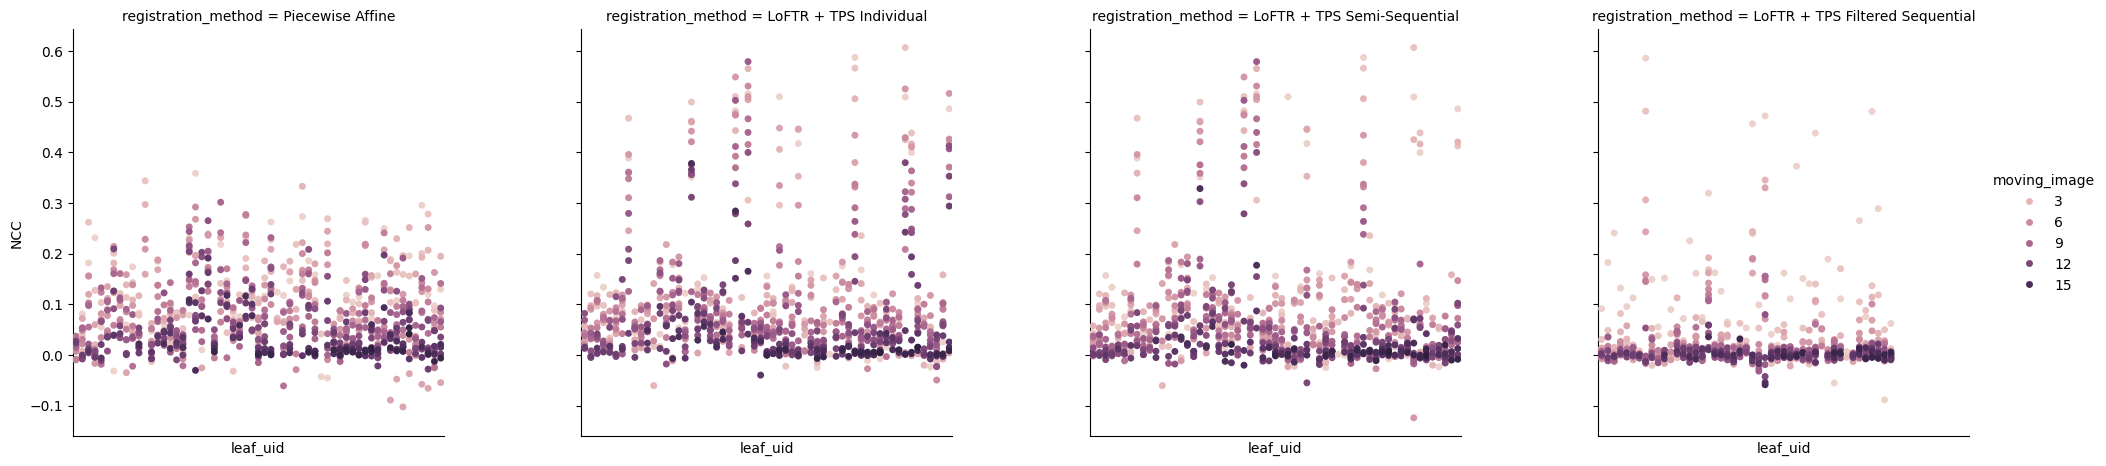

In [20]:
sns.catplot(data=df_full, x="leaf_uid", y="NCC", jitter=False, hue="moving_image", native_scale=True, col="registration_method")
plt.xticks([])
plt.show()

## Worst Performance

In [21]:
df_flagged = df_agg_leaf.copy()
df_flagged["bad"] = (
    df_flagged
    .groupby("registration_method")["Hausdorff_mean"]
    .rank(method="first", ascending=False)
    <= 10
)
df_flagged[df_flagged["bad"]][['leaf_uid', 'registration_method', 'Hausdorff_mean']].sort_values(by=["Hausdorff_mean"], ascending=[False]).head(7)

,leaf_uid,registration_method,Hausdorff_mean
217,ESWW0070054_17,Piecewise Affine,699.247375
143,ESWW0070040_6,Piecewise Affine,397.701874
214,ESWW0070054_16,Piecewise Affine,396.638971
135,ESWW0070040_4,Piecewise Affine,391.988678
202,ESWW0070054_12,Piecewise Affine,363.032648
11,ESWW0070020_2,Piecewise Affine,331.890350
208,ESWW0070054_14,Piecewise Affine,319.315399


In [22]:
bad_counts = (
    df_flagged[df_flagged["bad"]]
    .groupby("leaf_uid")["registration_method"]
    .nunique()
)

leaves_bad_in_one_method = bad_counts[bad_counts == 1].index#.tolist()

df_flagged[
    (df_flagged["bad"]) &
    (df_flagged["leaf_uid"].isin(leaves_bad_in_one_method))
][["leaf_uid", "registration_method", "Hausdorff_mean"]].sort_values(by=["Hausdorff_mean"], ascending=False)

,leaf_uid,registration_method,Hausdorff_mean
143,ESWW0070040_6,Piecewise Affine,397.701874
11,ESWW0070020_2,Piecewise Affine,331.890350
208,ESWW0070054_14,Piecewise Affine,319.315399
107,ESWW0070025_7,Piecewise Affine,299.111023
155,ESWW0070040_9,Piecewise Affine,287.745743
24,ESWW0070020_6,LoFTR + TPS Filtered Sequential,286.033554
160,ESWW0070044_2,LoFTR + TPS Filtered Sequential,264.795795
168,ESWW0070044_4,LoFTR + TPS Filtered Sequential,133.825288
116,ESWW0070040_1,LoFTR + TPS Filtered Sequential,116.866310
177,ESWW0070044_6,LoFTR + TPS Individual,98.141159


#### Inspection

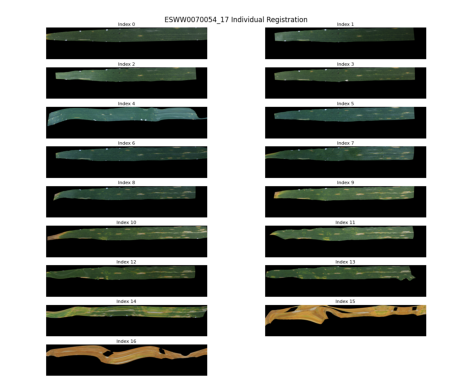

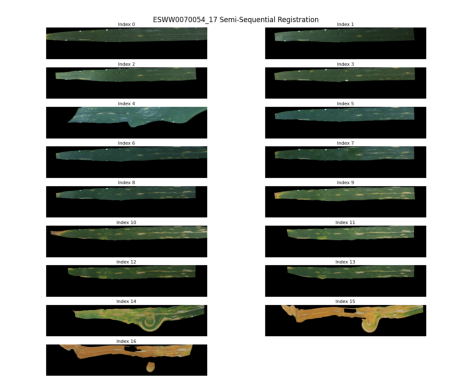

In [26]:
# all are bad

uid = "ESWW0070054_17"

# leaf = LeafDataset(
#     base_dir='../../leaf-image-sequences',
#     leaf_uid=uid, 
#     load=('target_images', 'target_masks'),
#     verbose=False
# )

# imgs, masks = fetch_registered_image_mask_seq(leaf, "Piecewise Affine", "roi")
# plot_image_series(imgs, title=title, n_cols=2, save_fig=False)
img = plt.imread(f"../temp/{uid}_individual.png")
plt.imshow(img)
plt.axis("off")
plt.show()
img = plt.imread(f"../temp/{uid}_semi_sequential.png")
plt.imshow(img)
plt.axis("off")
plt.show()
# img = plt.imread(f"../temp/{uid}_filtered_sequential.png")
# plt.imshow(img)
# plt.axis("off")
# plt.show()

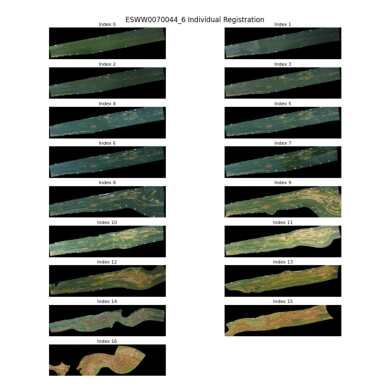

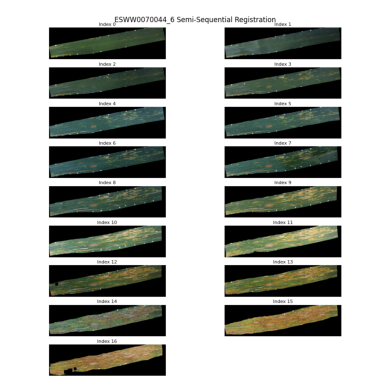

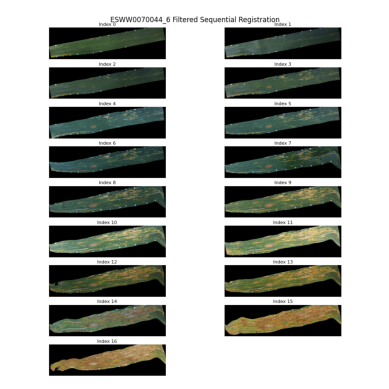

In [ ]:
# individual bad, others okay

uid = "ESWW0070044_6"

# leaf = LeafDataset(
#     base_dir='../../leaf-image-sequences',
#     leaf_uid=uid, 
#     load=('target_images', 'target_masks'),
#     verbose=False
# )

# imgs, masks = fetch_registered_image_mask_seq(leaf, "Piecewise Affine", "roi")
# plot_image_series(imgs, title=title, n_cols=2, save_fig=False)
img = plt.imread(f"../temp/{uid}_individual.png")
plt.imshow(img)
plt.axis("off")
plt.show()
img = plt.imread(f"../temp/{uid}_semi_sequential.png")
plt.imshow(img)
plt.axis("off")
plt.show()
img = plt.imread(f"../temp/{uid}_filtered_sequential.png")
plt.imshow(img)
plt.axis("off")
plt.show()

## Best Performance

In [28]:
# df_flagged = df_agg_leaf.copy()
df_flagged["good"] = (
    df_flagged
    .groupby("registration_method")["Hausdorff_mean"]
    .rank(method="first", ascending=True)
    <= 10
)
df_flagged[df_flagged["good"]][['leaf_uid', 'registration_method', 'Hausdorff_mean']].sort_values(by=["Hausdorff_mean"], ascending=[True]).head(7)

,leaf_uid,registration_method,Hausdorff_mean
61,ESWW0070023_5,LoFTR + TPS Individual,9.305260
70,ESWW0070023_7,LoFTR + TPS Semi-Sequential,10.200328
82,ESWW0070025_1,LoFTR + TPS Semi-Sequential,11.569826
106,ESWW0070025_7,LoFTR + TPS Semi-Sequential,12.346536
73,ESWW0070023_8,LoFTR + TPS Individual,12.379382
62,ESWW0070023_5,LoFTR + TPS Semi-Sequential,12.452408
74,ESWW0070023_8,LoFTR + TPS Semi-Sequential,13.003024


In [29]:
good_counts = (
    df_flagged[df_flagged["good"]]
    .groupby("leaf_uid")["registration_method"]
    .nunique()
)

leaves_good_in_one_method = good_counts[good_counts == 1].index#.tolist()

df_flagged[
    (df_flagged["good"]) &
    (df_flagged["leaf_uid"].isin(leaves_good_in_one_method))
][["leaf_uid", "registration_method", "Hausdorff_mean"]].sort_values(by=["Hausdorff_mean"], ascending=True)


,leaf_uid,registration_method,Hausdorff_mean
18,ESWW0070020_4,LoFTR + TPS Semi-Sequential,16.626402
172,ESWW0070044_5,LoFTR + TPS Filtered Sequential,18.264673
4,ESWW0070020_10,LoFTR + TPS Filtered Sequential,23.982333
91,ESWW0070025_2,Piecewise Affine,53.000000
87,ESWW0070025_10,Piecewise Affine,58.155594
3,ESWW0070020_1,Piecewise Affine,62.987316
131,ESWW0070040_3,Piecewise Affine,65.004845
27,ESWW0070020_6,Piecewise Affine,68.883957


#### Inspection

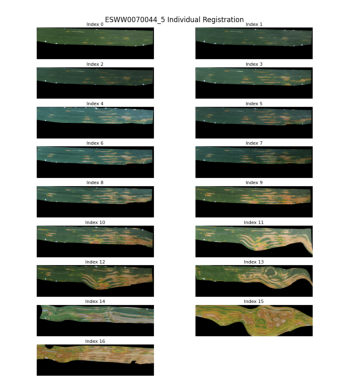

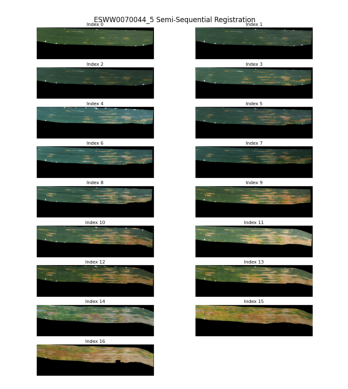

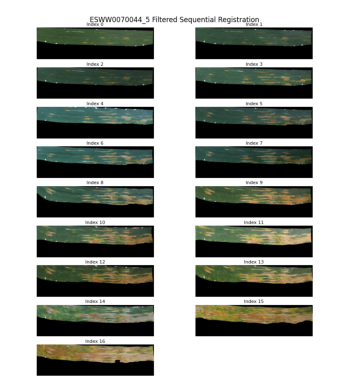

In [ ]:
# filtered sequential good, others bad

uid = "ESWW0070044_5"

# leaf = LeafDataset(
#     base_dir='../../leaf-image-sequences',
#     leaf_uid=uid, 
#     load=('target_images', 'target_masks'),
#     verbose=False
# )

# imgs, masks = fetch_registered_image_mask_seq(leaf, "Piecewise Affine", "roi")
# plot_image_series(imgs, title=title, n_cols=2, save_fig=False)
img = plt.imread(f"../temp/{uid}_individual.png")
plt.imshow(img)
plt.axis("off")
plt.show()
img = plt.imread(f"../temp/{uid}_semi_sequential.png")
plt.imshow(img)
plt.axis("off")
plt.show()
img = plt.imread(f"../temp/{uid}_filtered_sequential.png")
plt.imshow(img)
plt.axis("off")
plt.show()

In [24]:
df_full.sort_values(["MI"], ascending=False).head(7)

,leaf_uid,registration_method,fixed_image,moving_image,MSE,NCC,MI,SSIM,IoU,Hausdorff
402,ESWW0070023_5,LoFTR + TPS ROI,0,1,0.003527,0.705855,1.077173,0.734989,0.982719,17.000000
506,ESWW0070023_9,LoFTR + TPS ROI,0,1,0.010650,0.754358,1.072842,0.763037,0.963806,18.110771
289,ESWW0070023_10,Pairwise Affine,0,1,0.008278,0.228845,1.064466,0.458446,0.942078,70.000000
476,ESWW0070023_8,LoFTR + TPS ROI,0,1,0.016635,0.658201,1.063523,0.657549,0.956137,31.000000
480,ESWW0070023_8,LoFTR + TPS ROI,0,5,0.009766,0.662146,1.060622,0.659368,0.968399,26.000000
491,ESWW0070023_9,Pairwise Affine,0,1,0.013271,0.358649,1.059374,0.472423,0.928104,62.514000
290,ESWW0070023_10,Pairwise Affine,0,2,0.009582,0.343835,1.058519,0.481673,0.942035,70.000000


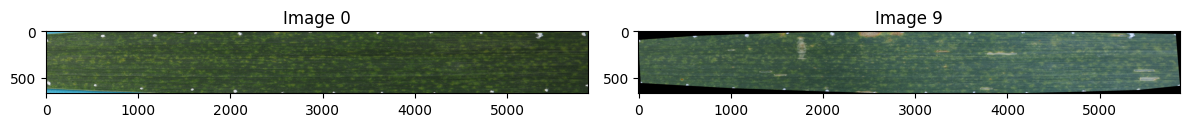

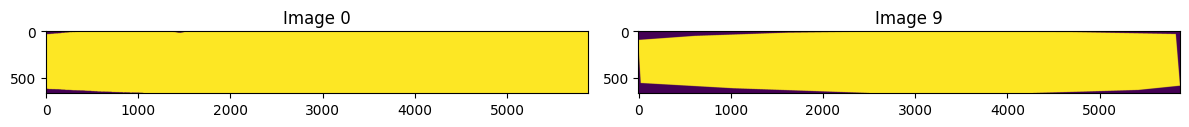

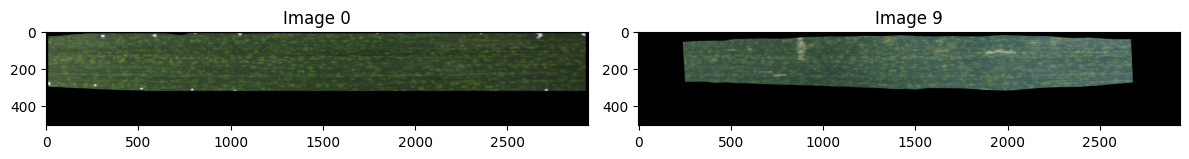

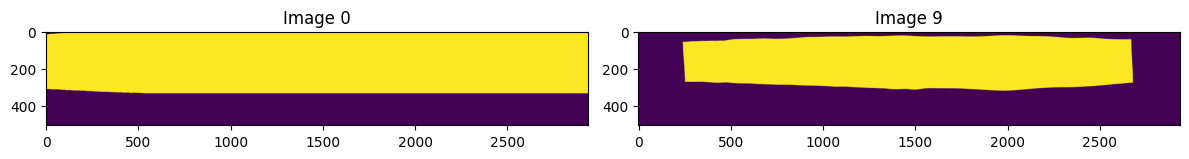

In [ ]:
# loftr good, piecewise less good
moving_ind = 9

leaf = LeafDataset(
    base_dir='../../leaf-image-sequences',
    leaf_uid="ESWW0070023_9", 
    load=('target_images', 'target_masks', 'leaf_masks', 'rois', 'images', 'keypoints'),
    verbose=False
)

fixed, moving, fixed_mask, moving_mask = fetch_registered_image_mask_pair(leaf, 0, moving_ind, "Piecewise Affine")
fig, ax = plot_image_pair(fixed, convert_image_to_tensor(moving), 0, moving_ind)
fig.show()
fig, ax = plot_image_pair(fixed_mask, convert_image_to_tensor(moving_mask), 0, moving_ind)
fig.show()
fixed, moving, fixed_mask, moving_mask = fetch_registered_image_mask_pair(leaf, 0, moving_ind, "LoFTR + TPS ROI", old=True)
fig, ax = plot_image_pair(fixed, convert_image_to_tensor(moving), 0, moving_ind)
fig.show()
fig, ax = plot_image_pair(fixed_mask, convert_image_to_tensor(moving_mask), 0, moving_ind)
fig.show()
# fixed, moving, fixed_mask, moving_mask = fetch_registered_image_mask_pair(leaf, 0, moving_ind, "LoFTR + TPS ROI with Markers")
# fig, ax = plot_image_pair(fixed, convert_image_to_tensor(moving), 0, moving_ind)
# fig.show()
# fig, ax = plot_image_pair(fixed_mask, convert_image_to_tensor(moving_mask), 0, moving_ind)
# fig.show()

### Hausdorff Metric Inspection

In [27]:
uid = "ESWW0070054_1"
# uid = "ESWW0070054_12"
uid.rsplit('_')[0][-2:]

'54'

In [30]:
df_full['num_id'] = df_full.leaf_uid.map(lambda uid: int(uid.rsplit('_')[0][-2:]))
df_full.sample(5)

,leaf_uid,registration_method,leaf_style,fixed_image,moving_image,MSE,NCC,MI,SSIM,IoU,Hausdorff,num_id
1638,ESWW0070040_9,LoFTR + TPS Semi-Sequential,Leaf ROI,0,8,0.013550,0.008469,1.009003,0.649143,0.891051,52.153618,40
1520,ESWW0070040_7,Piecewise Affine,Leaf ROI,0,12,0.067959,0.048661,1.021629,0.295940,0.900689,65.767471,40
2042,ESWW0070044_9,LoFTR + TPS Individual,Leaf ROI,0,7,0.013547,0.062507,1.006947,0.722533,0.949618,14.000000,44
738,ESWW0070023_8,LoFTR + TPS Individual,Leaf ROI,0,7,0.024186,0.119316,1.007219,0.613605,0.949100,14.000000,23
2574,ESWW0070054_19,LoFTR + TPS Semi-Sequential,Leaf ROI,0,5,0.005401,0.025392,1.009102,0.754220,0.968723,8.000000,54


In [78]:
checked_uids = []
checked_uids = ["ESWW0070044_3", "ESWW0070044_5", "ESWW0070054_1", "ESWW0070044_6", "ESWW0070040_3", "ESWW0070040_8", "ESWW0070044_4"]
df_full[(df_full.num_id >= 40) & (~df_full.leaf_uid.isin(checked_uids))][['leaf_uid', 'registration_method', 'moving_image', 'Hausdorff', 'IoU']].sort_values(by=["Hausdorff", "IoU"], ascending=True).head(20)

,leaf_uid,registration_method,moving_image,Hausdorff,IoU
2280,ESWW0070054_13,LoFTR + TPS Individual,9,6.324555,0.972262
2037,ESWW0070044_9,LoFTR + TPS Individual,2,6.708204,0.982327
2054,ESWW0070044_9,LoFTR + TPS Semi-Sequential,2,6.708204,0.982327
1265,ESWW0070040_10,LoFTR + TPS Individual,3,7.000000,0.959467
1280,ESWW0070040_10,LoFTR + TPS Semi-Sequential,3,7.000000,0.959467
1700,ESWW0070044_2,LoFTR + TPS Individual,2,7.000000,0.968919
1716,ESWW0070044_2,LoFTR + TPS Semi-Sequential,2,7.000000,0.968919
1660,ESWW0070044_1,LoFTR + TPS Individual,2,7.000000,0.971729
1672,ESWW0070044_1,LoFTR + TPS Semi-Sequential,2,7.000000,0.971729
1707,ESWW0070044_2,LoFTR + TPS Individual,9,7.071068,0.973128


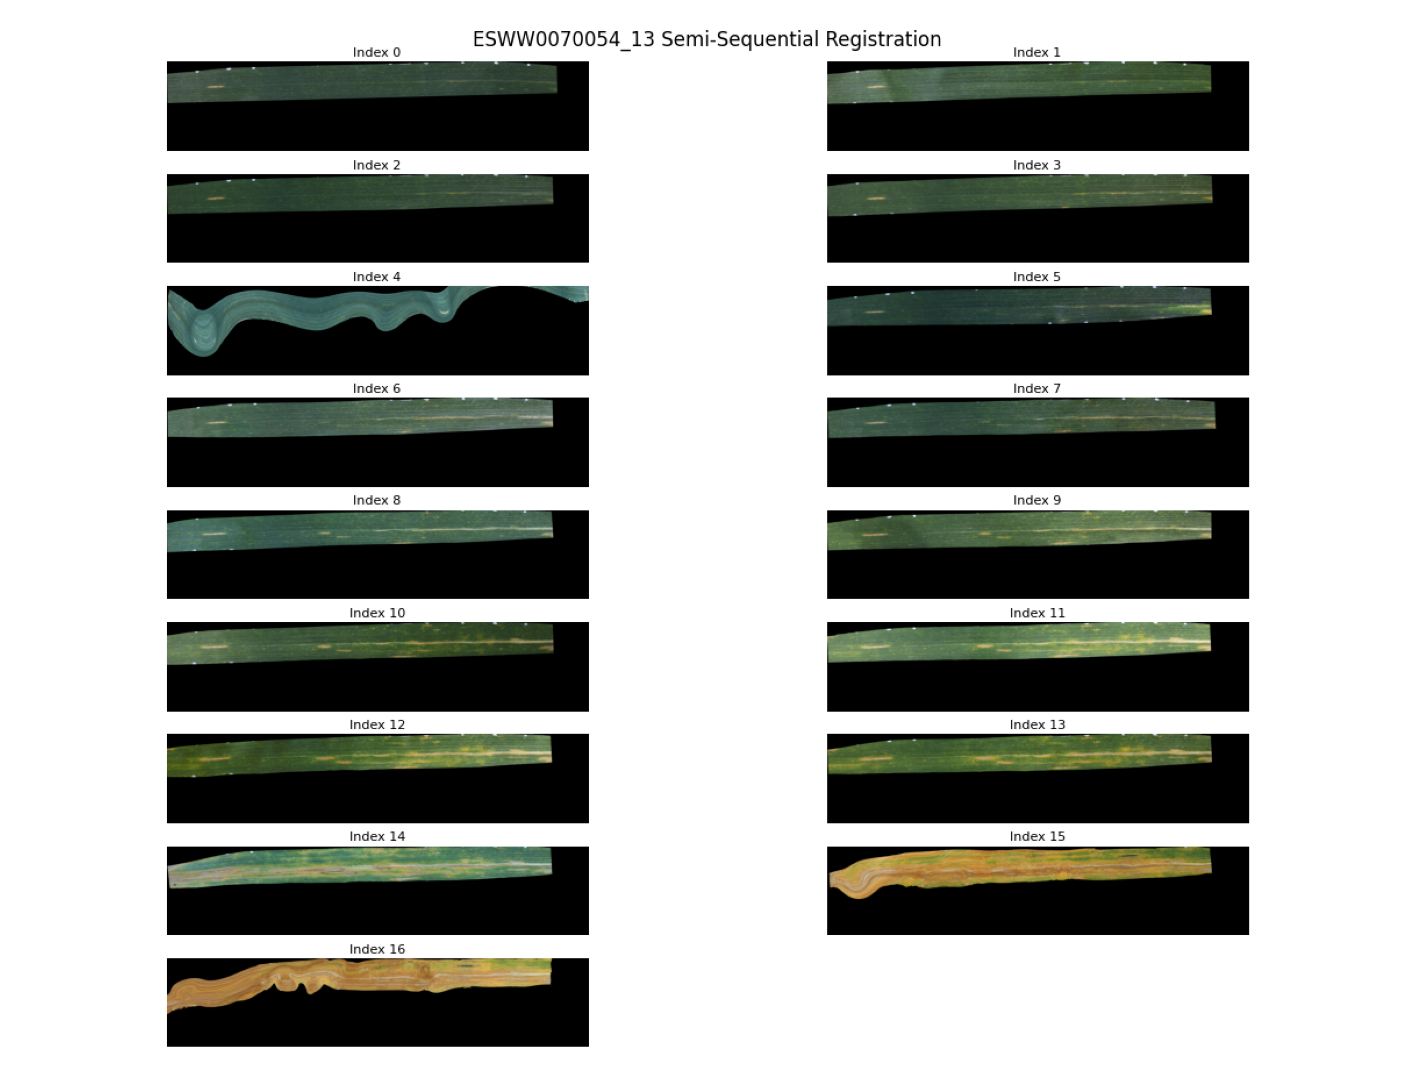

In [81]:
uid = "ESWW0070054_13"
# method = "piecewise_affine"
method = "semi_sequential"
# method = "individual"
# method = "filtered_sequential"

if method == "piecewise_affine":
    leaf = LeafDataset(
        base_dir='../../leaf-image-sequences',
        leaf_uid=uid, 
        load=('target_images', 'target_masks'),
        verbose=False
    )

    imgs, masks = fetch_registered_image_mask_seq(leaf, "Piecewise Affine", "roi")
    plot_image_series(imgs, title=title, n_cols=2, save_fig=False)
else:
    img = plt.imread(f"../temp/{uid}_{method}.png")
    plt.figure(figsize=(18,18))
    plt.imshow(img)
    plt.axis("off")
    plt.show()

In [82]:
uid = "ESWW0070054_13"

# method = "Piecewise Affine"
method = "LoFTR + TPS Semi-Sequential"
# method = "LoFTR + TPS Individual"
# method = "LoFTR + TPS Filtered Sequential"

mov_idx = [7]
mov_idx = np.arange(1,20)

df_full[(df_full.registration_method == method) & (df_full.leaf_uid == uid) & (df_full.moving_image.isin(mov_idx))][['leaf_uid', 'registration_method', 'moving_image', 'Hausdorff', 'IoU']]

,leaf_uid,registration_method,moving_image,Hausdorff,IoU
2288,ESWW0070054_13,LoFTR + TPS Semi-Sequential,1,35.000000,0.946363
2289,ESWW0070054_13,LoFTR + TPS Semi-Sequential,2,22.022715,0.971894
2290,ESWW0070054_13,LoFTR + TPS Semi-Sequential,3,27.892651,0.947803
2291,ESWW0070054_13,LoFTR + TPS Semi-Sequential,4,187.123718,0.540633
2292,ESWW0070054_13,LoFTR + TPS Semi-Sequential,5,34.000000,0.935303
2293,ESWW0070054_13,LoFTR + TPS Semi-Sequential,6,24.000000,0.953798
2294,ESWW0070054_13,LoFTR + TPS Semi-Sequential,7,11.000000,0.965446
2295,ESWW0070054_13,LoFTR + TPS Semi-Sequential,8,24.002298,0.936461
2296,ESWW0070054_13,LoFTR + TPS Semi-Sequential,9,33.000000,0.957837
2297,ESWW0070054_13,LoFTR + TPS Semi-Sequential,10,20.893787,0.961603


In [ ]:
checked_uids = []
checked_uids = ["ESWW0070020_10"]
df_full[(df_full.registration_method == "Piecewise Affine") & (~df_full.leaf_uid.isin(checked_uids))][['leaf_uid', 'registration_method', 'moving_image', 'Hausdorff', 'IoU']].sort_values(by=["Hausdorff", "IoU"], ascending=True).head(20)

,leaf_uid,registration_method,moving_image,Hausdorff,IoU
1254,ESWW0070040_10,Piecewise Affine,7,43.000000,0.914253
1253,ESWW0070040_10,Piecewise Affine,6,43.000000,0.914391
1255,ESWW0070040_10,Piecewise Affine,8,43.000000,0.914533
1249,ESWW0070040_10,Piecewise Affine,2,43.000000,0.917875
1250,ESWW0070040_10,Piecewise Affine,3,43.000000,0.918101
124,ESWW0070020_3,Piecewise Affine,5,47.000000,0.955959
123,ESWW0070020_3,Piecewise Affine,4,47.000000,0.956146
121,ESWW0070020_3,Piecewise Affine,2,47.000000,0.956172
127,ESWW0070020_3,Piecewise Affine,8,47.000000,0.956176
122,ESWW0070020_3,Piecewise Affine,3,47.000000,0.956179


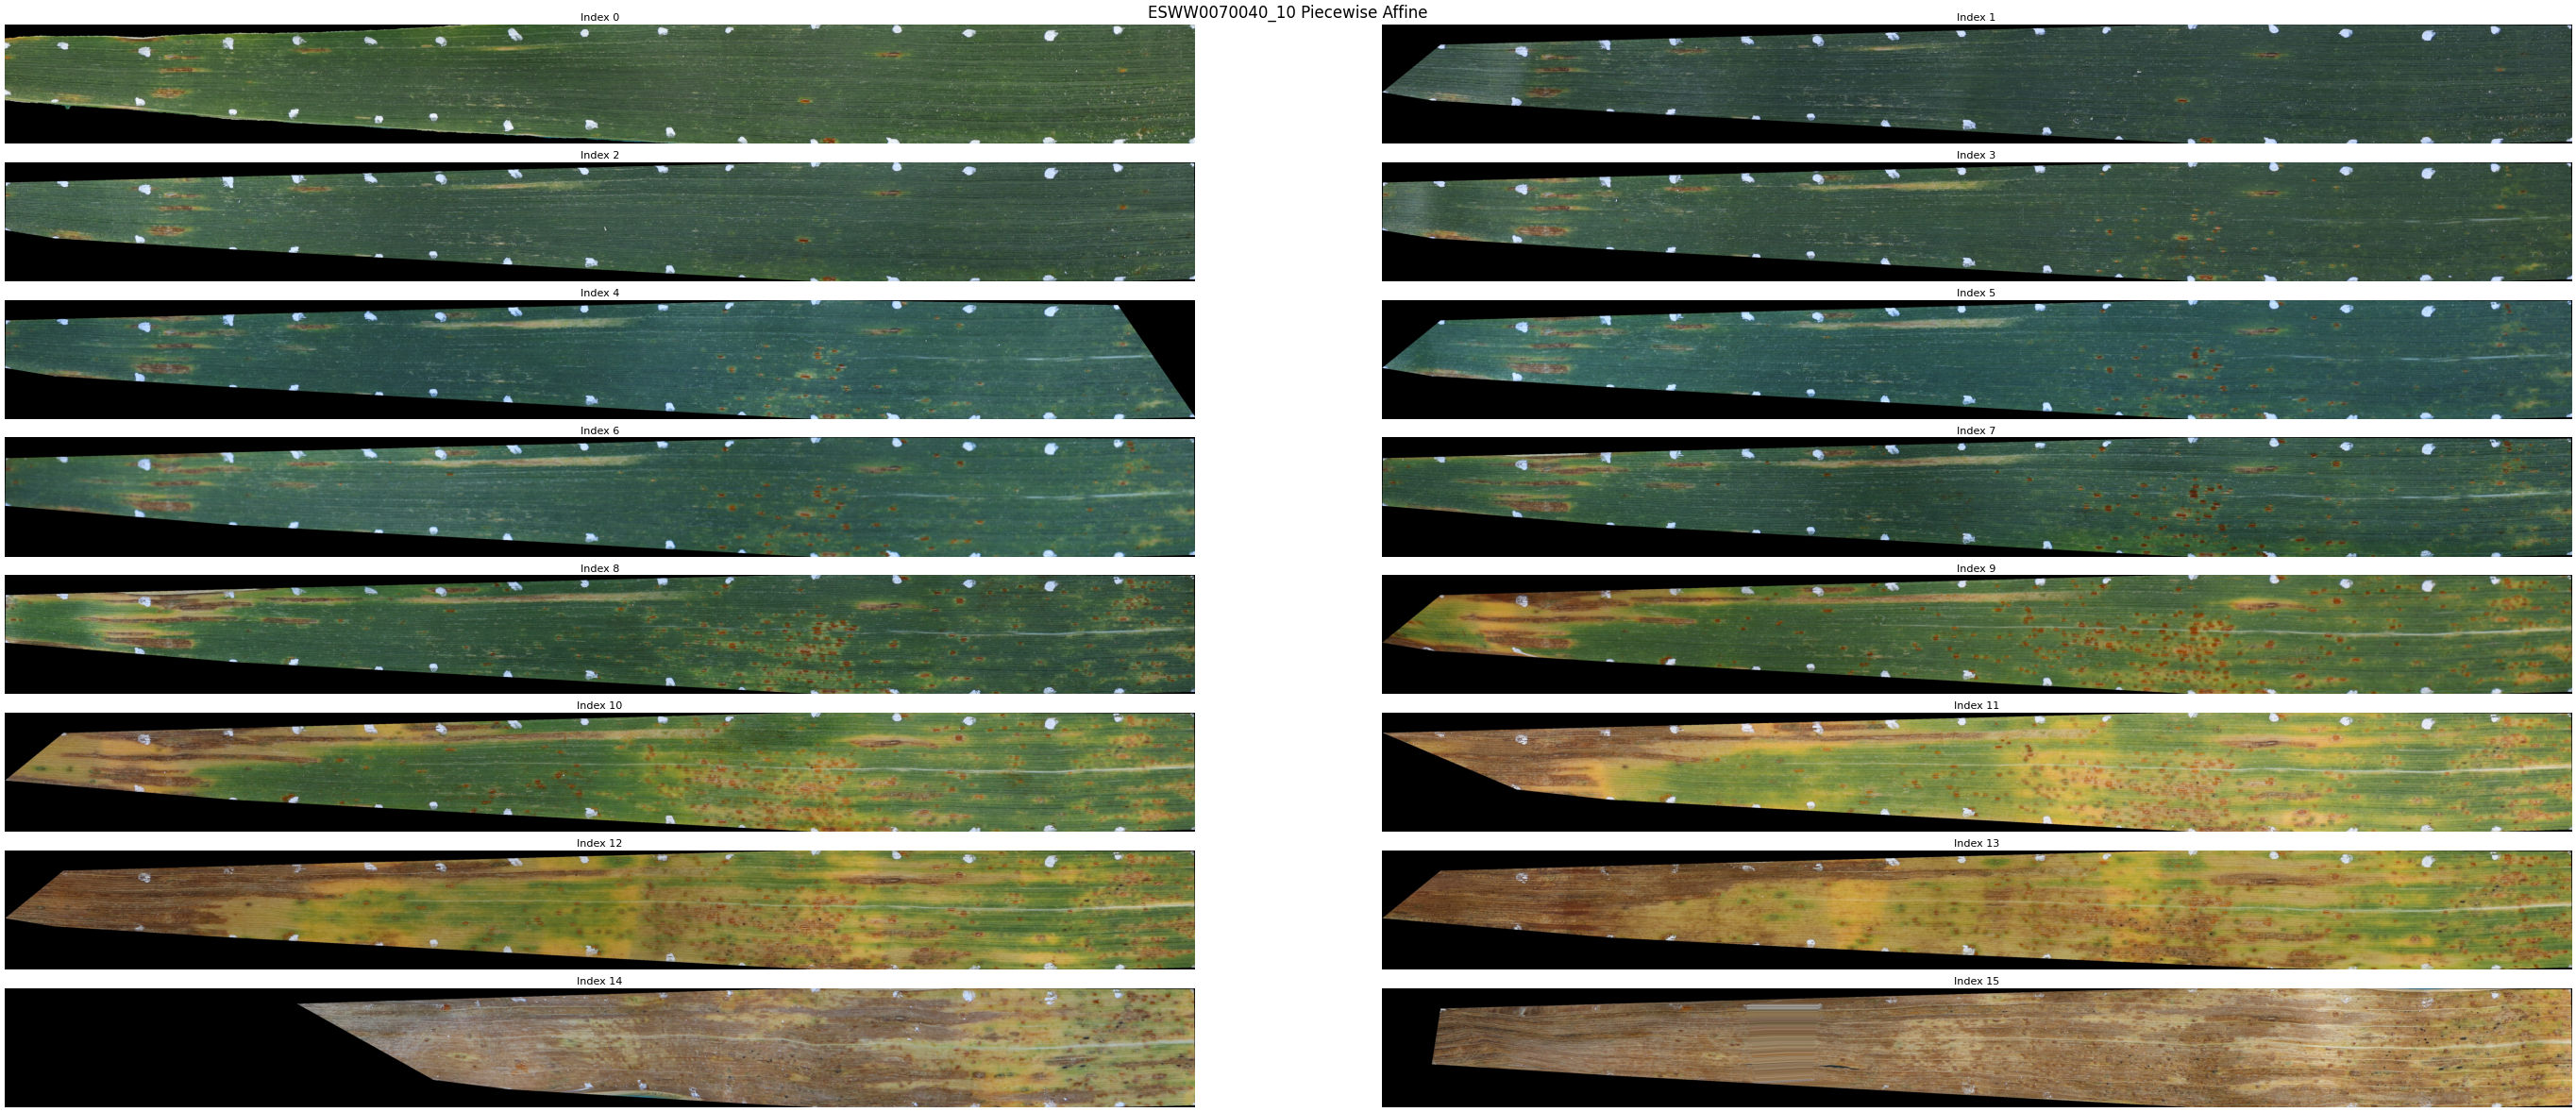

In [89]:
from leafalignment.registration import fetch_registered_image_mask_seq
uid = "ESWW0070040_10"

leaf = LeafDataset(
    base_dir='../../leaf-image-sequences',
    leaf_uid=uid, 
    load=('target_images', 'target_masks'),
    verbose=False
)

imgs, masks = fetch_registered_image_mask_seq(leaf, "Piecewise Affine", "roi")
plot_image_series(imgs, title=f"{uid} Piecewise Affine", n_cols=2, save_fig=False)


In [90]:
uid = "ESWW0070040_10"

method = "Piecewise Affine"

mov_idx = np.arange(1,20)

df_full[(df_full.registration_method == method) & (df_full.leaf_uid == uid) & (df_full.moving_image.isin(mov_idx))][['leaf_uid', 'registration_method', 'moving_image', 'Hausdorff', 'IoU']]

,leaf_uid,registration_method,moving_image,Hausdorff,IoU
1248,ESWW0070040_10,Piecewise Affine,1,82.131516,0.902462
1249,ESWW0070040_10,Piecewise Affine,2,43.000000,0.917875
1250,ESWW0070040_10,Piecewise Affine,3,43.000000,0.918101
1251,ESWW0070040_10,Piecewise Affine,4,203.781311,0.876125
1252,ESWW0070040_10,Piecewise Affine,5,82.131516,0.902447
1253,ESWW0070040_10,Piecewise Affine,6,43.000000,0.914391
1254,ESWW0070040_10,Piecewise Affine,7,43.000000,0.914253
1255,ESWW0070040_10,Piecewise Affine,8,43.000000,0.914533
1256,ESWW0070040_10,Piecewise Affine,9,82.131516,0.902449
1257,ESWW0070040_10,Piecewise Affine,10,82.131516,0.898861


## Variance Analysis

In [23]:
rows = []

for keys, g in df_full.groupby(group_cols):
    n = g["leaf_uid"].nunique() # number of samples
    if n < 2:
        # not enough samples to compute sample variance
        continue

    tval = t.ppf(0.975, n - 1)

    # compute confidence interval half-width for each metric
    for metric in metrics:
        s = g[metric].std(ddof=1) # sample standard deviation
        half_width = tval * s / np.sqrt(n) # width of confidence interval
        m = g[metric].mean()
        
        rows.append({
            "registration_method": keys[0],
            "fixed_image": keys[1],
            "moving_image": keys[2],
            "metric": metric,
            "mean": m,
            "ci_half_width": half_width,            
        })

ci_param_df = pd.DataFrame(rows)
ci_param_df.head(5)


,registration_method,fixed_image,moving_image,metric,mean,ci_half_width
0,LoFTR + TPS ROI,0,1,MSE,0.007963,0.001651
1,LoFTR + TPS ROI,0,1,NCC,0.185808,0.097086
2,LoFTR + TPS ROI,0,1,MI,1.020832,0.007947
3,LoFTR + TPS ROI,0,1,SSIM,0.487167,0.054920
4,LoFTR + TPS ROI,0,1,IoU,0.917000,0.030367


In [27]:
metric_tol = (
    ci_param_df
    .groupby(["registration_method", "metric"])#["ci_half_width"]
    #.max()
    .agg( overall_mean=("mean", "mean"), max_ci_half_width=("ci_half_width", "max"))
    .reset_index()
)
rel_tol = 0.05 # 5% relative tolerance
metric_tol["tolerance"] = rel_tol * metric_tol["overall_mean"].abs()
metric_tol["Confident"] = metric_tol["max_ci_half_width"] <= metric_tol["tolerance"]
metric_tol['n_target'] = np.ceil(n_uids * (metric_tol['max_ci_half_width'] / metric_tol['tolerance'])**2).astype(int)
metric_tol

,registration_method,metric,overall_mean,max_ci_half_width,tolerance,Confident,n_target
0,LoFTR + TPS,MI,1.017236,0.004566,0.050862,True,1
1,LoFTR + TPS,MSE,0.043189,0.303678,0.002159,False,1245915
2,LoFTR + TPS,NCC,0.099139,0.043457,0.004957,False,4843
3,LoFTR + TPS,SSIM,0.695947,0.072285,0.034797,False,272
4,Pairwise Affine,MI,1.016601,0.067343,0.050830,False,111
5,Pairwise Affine,MSE,0.038126,0.382457,0.001906,False,2535788
6,Pairwise Affine,NCC,0.061739,0.141039,0.003087,False,131512
7,Pairwise Affine,SSIM,0.297321,0.146280,0.014866,False,6100


For each registration method and metric, the half-width of the Confidence Interval $CI$ indicates that the true mean of that metric lies within $\pm CI$ with probability $95\%$.  
The tolerance is relative to the mean over all metric values, with a relative tolerance of $5\%$.  
`n_target` is an estimate of how many samples would be needed to achieve the desired tolerance.  